# Нейросеть для автодополнения текстов

Обучение и сравнение моделей для автодополнения текстов в мобильном мессенджере

**[GitHub проекта](https://github.com/AlekseiBogachev/TextAutocompletionOnWikiText2)**

**[Проект и артефакты моделирования - Google Drive](https://drive.google.com/drive/folders/1LqUjef_0fs7pIUl-GFuABOlrCoQyZtLC?usp=sharing)**

## Подготовка окружения

Модели обучались в Google Colab. Ниже приведены команды специфические для
настройки проекта в Google Colab после клонирования репозитория.

**Запуск проекта возможен на локальной машине после установики пакетов с помощью
`pip` или `poetry`**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/yapracticum_nlp/sprint_2_project/TextAutocompletionOnWikiText2")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!git checkout models --
!git branch -a
!git pull

M	TextAutocompletionOnWikiText2.ipynb
M	config.yaml
M	src/text_autocompl/training.py
Already on 'models'
Your branch is up to date with 'origin/models'.
  main
* models
  remotes/origin/HEAD -> origin/main
  remotes/origin/main
  remotes/origin/models
Already up to date.


In [3]:
!pip install ./

Processing /content/drive/MyDrive/Colab Notebooks/yapracticum_nlp/sprint_2_project/TextAutocompletionOnWikiText2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for text_autocompl: filename=text_autocompl-0.1.0-py3-none-any.whl size=11604 sha256=9f01dcd1c03f4cbacff1b9279bb2606212a77d0300b121ce0c186985cd8cc8c5
  Stored in directory: /tmp/pip-ephem-wheel-cache-fjdt7o1t/wheels/ef/9b/84/7be49fa770237269613b2c7317437d6119fce4863d1fb3024d
Successfully built text_autocompl
  Attempting uninstall: text_autocompl
    Found existing installation: text_autocompl 0.1.0
    Uninstalling text_autocompl-0.1.0:
      Successfully uninstalled text_autocompl-0.1.0


In [4]:
!rm -rf ./logs/*.log

## Импорт необходимых модулей

In [5]:
import logging
from pprint import pprint

from dotenv import load_dotenv
import matplotlib.pyplot as plt

from text_autocompl import set_random_state
from text_autocompl.data import get_dataset, dataset_info
from text_autocompl.files import read_config
from text_autocompl.log import get_logger
from text_autocompl.training import (
    train,
    test_custom_model,
    test_distilgpt2,
    predict_custom_model,
    predict_distilgpt2
)

# load_dotenv()

## Константы

In [ ]:
SEED = 42

## Фиксация начального состояния генераторов случайных чисел

In [7]:
set_random_state(seed=SEED)

## Настройка логирования

In [8]:
nb_logger = get_logger(log_level=logging.DEBUG)

## Чтение параметров из `config.yaml`

In [9]:
config = read_config(logger=nb_logger)

print("Начальная конфигурация проекта:")
pprint(config)

2026-05-25 21:57:18,283 DEBUG Read config from the file './config.yaml'
DEBUG:txt_logger:Read config from the file './config.yaml'


Начальная конфигурация проекта:
{'data_dir': './data/',
 'distilgpt2': {'batch_size': 64,
                'generate_max_new_tokens': 1,
                'max_len': 512,
                'min_text_len': 10},
 'grad_clipping_params': {'max_norm': 1.0, 'norm_type': 2.0},
 'metrics_dir': './metrics/',
 'model': {'checkpoint_name': None,
           'model_params': {'dropout': 0.2,
                            'embedding_size': 128,
                            'hidden_size': 128,
                            'n_rec_layers': 4,
                            'resid_connections': True},
           'model_type': 'LSTM'},
 'models_dir': './models/',
 'optimizer_params': {'lr': 0.001, 'weight_decay': 0.01},
 'plots_dir': './plots/',
 'tokenizer': {'max_len': 150, 'n_most_freq_words': 10000},
 'training_params': {'batch_size': 128,
                     'label_smoothing': 0.2,
                     'n_epochs': 30,
                     'num_workers': 8}}


## WikiText-2

### Загрузка датасета

In [10]:
dataset = get_dataset(config, logger=nb_logger)
display(dataset)

2026-05-25 21:57:21,000 DEBUG Load from 'wikitext-2-raw-v1' form 'Salesforce/wikitext'
DEBUG:txt_logger:Load from 'wikitext-2-raw-v1' form 'Salesforce/wikitext'


Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

### Разведочный анализ `train`

Длина датасета: 36718

Примеры текстов:

id=3799
 Jim Halpert ( John Krasinski ) has returned to Scranton full time , saying he has realized that he can 't devote himself to both his family and his new job , and has decided to go " all in " on his family since that is what makes him most happy . David asks Jim his opinion on promoting Dwight , and Jim says that Dwight deserves the job and will be a great manager . Dwight then appoints Jim the new assistant to the regional manager . Darryl Philbin ( Craig Robinson ) informs Jim that Athlead has found a buyer and wants them to do a promotional tour around the country for three months . With undisguised regret , Jim says he will not do the tour because he cannot put his wife Pam ( Jenna Fischer ) through that , unaware that Pam is listening in . 


id=8426


id=7335
 The invasion was legitimised by the provisions of the Papal Bull Laudabiliter , issued by Adrian IV in 1155 . The bull encouraged Henry to take control in Ireland in order to

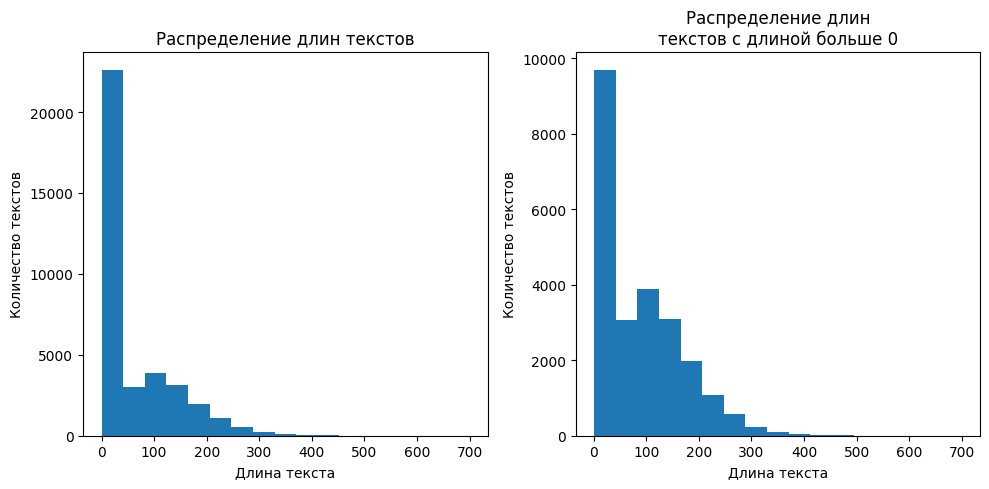

In [11]:
dataset_info(dataset["train"])

### Разведочный анализ `validation`

Длина датасета: 3760

Примеры текстов:

id=3055
 The next day , Churchill filed a lawsuit in state court claiming that the firing was retribution for his expressing politically unpopular views . The jury in Churchill 's suit for reinstatement weighed the university 's claims of academic misconduct per jury instructions it received in the case . As Stanley Fish said , " It was the jury ’ s task to determine whether Churchill ’ s dismissal would have occurred independently of the adverse political response to his constitutionally protected statements . " The jury found that the alleged misconduct would not have led to Churchill 's firing and rejected the university 's academic misconduct claim as the grounds for dismissal . On April 1 , 2009 , a Colorado jury found that Churchill had been wrongly fired , and awarded $ 1 in damages . As one of the jurors said later in a press interview , " it wasn 't a slap in his face or anything like that when we didn 't give him any money . It 's just 

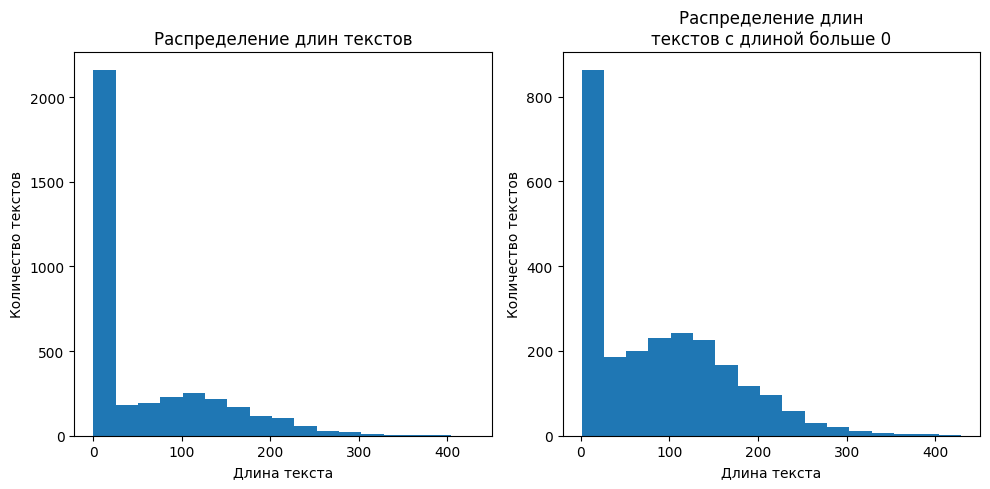

In [12]:
dataset_info(dataset["validation"])

### Разведочный анализ `test`

Длина датасета: 4358

Примеры текстов:

id=3078


id=1034
 = = = Loan to Oldham Athletic = = = 


id=676
 Ironclads were widely used in South America . Both sides used ironclads in the Chincha Islands War between Spain and the combined forces of Peru and Chile in the early 1860s . The powerful Spanish Numancia participated in the Battle of Callao but was unable to inflict significant damage to the Callao defences . Besides , Peru was able to deploy two locally built ironclads based on American Civil War designs , the Loa ( a wooden ship converted into a casemate ironclad ) and the Victoria ( a small monitor armed with a single 68 @-@ pdr gun ) , as well as two British @-@ built ironclads : Independencia , a centre @-@ battery ship , and the turret ship Huáscar . Numancia was the first ironclad to circumnavigate the world , arriving in Cádiz on 20 September 1867 , and earning the motto : " Enloricata navis que primo terram circuivit " [ " First ironclad ship to sail around the world " ]

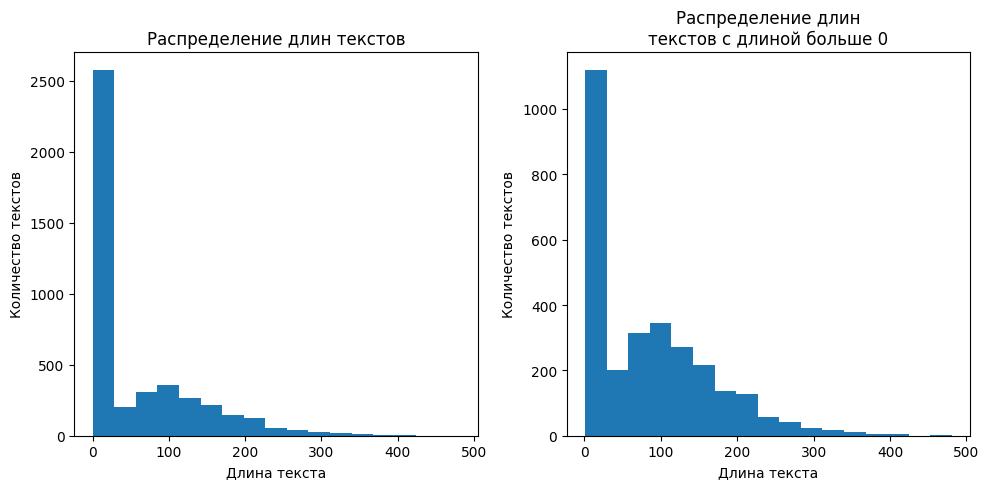

In [13]:
dataset_info(dataset["test"])

### Выводы

- Датасет содержит тексты нулевой длины, их следует игнорировать
при загрузке данных.
- Распределения длин исильно смещены и имеют 2 моды.
- Из-за большого количества короктких текстов среднее значение и медиана имеют
значения 56 и 8 соответственно.
- Максимльную длину текста, подаваемого на вход моделей на основе `LSTM` и `GRU`
ограничем значением второй моды - приблизительно 150 (параметр
`tokenizer:max_len` в *config.py*).
- Для предобученной `distilgpt2` максимальную длину установим равной 512 (
параметр `distilgpt2:max_len` в *config.py*), чтобы покрыть тексты максимальной
длины.

## Обучение моделей

**Для ускорения тренинга используем G4 GPU в Google Colab**

### LSTM

In [14]:
print("Параметры")
pprint(config["model"])

Параметры
{'checkpoint_name': None,
 'model_params': {'dropout': 0.2,
                  'embedding_size': 128,
                  'hidden_size': 128,
                  'n_rec_layers': 4,
                  'resid_connections': True},
 'model_type': 'LSTM'}


In [15]:
lstm_train_metrics_df, _ = train(config, logger=nb_logger)
del _

2026-05-25 21:57:32,078 INFO Start training
INFO:txt_logger:Start training
2026-05-25 21:57:32,078 DEBUG Parameters: {'data_dir': './data/', 'models_dir': './models/', 'metrics_dir': './metrics/', 'plots_dir': './plots/', 'tokenizer': {'max_len': 150, 'n_most_freq_words': 10000}, 'model': {'model_type': 'LSTM', 'model_params': {'embedding_size': 128, 'n_rec_layers': 4, 'hidden_size': 128, 'dropout': 0.2, 'resid_connections': True}, 'checkpoint_name': None}, 'optimizer_params': {'lr': 0.001, 'weight_decay': 0.01}, 'grad_clipping_params': {'max_norm': 1.0, 'norm_type': 2.0}, 'training_params': {'n_epochs': 30, 'batch_size': 128, 'num_workers': 8, 'label_smoothing': 0.2}, 'distilgpt2': {'max_len': 512, 'min_text_len': 10, 'batch_size': 64, 'generate_max_new_tokens': 1}}
DEBUG:txt_logger:Parameters: {'data_dir': './data/', 'models_dir': './models/', 'metrics_dir': './metrics/', 'plots_dir': './plots/', 'tokenizer': {'max_len': 150, 'n_most_freq_words': 10000}, 'model': {'model_type': 'LSTM

  0%|          | 0/30 [00:00<?, ?it/s]

2026-05-25 21:57:36,485 INFO Epoch 0 / 30. Training
INFO:txt_logger:Epoch 0 / 30. Training


  0%|          | 0/227 [00:00<?, ?it/s]

2026-05-25 21:57:47,515 INFO Epoch 0 / 30. Validation
INFO:txt_logger:Epoch 0 / 30. Validation


...

2026-05-25 22:03:03,416 INFO Epoch 28 / 30. Metrics: {'time': '2026_05_25T22_03_03', 'epoch': 28, 'train_loss': 5.461692888719893, 'train_perplexity': 235.49575521279112, 'train_acc': 0.2932455946153698, 'val_loss': 5.710432982296474, 'val_acc': 0.2756722241929762, 'val_perplexity': 302.0018014116973}
INFO:txt_logger:Epoch 28 / 30. Metrics: {'time': '2026_05_25T22_03_03', 'epoch': 28, 'train_loss': 5.461692888719893, 'train_perplexity': 235.49575521279112, 'train_acc': 0.2932455946153698, 'val_loss': 5.710432982296474, 'val_acc': 0.2756722241929762, 'val_perplexity': 302.0018014116973}
2026-05-25 22:03:03,420 INFO Save metrics to metrics/metrics_2026_05_25T21_57_36.csv
INFO:txt_logger:Save metrics to metrics/metrics_2026_05_25T21_57_36.csv
2026-05-25 22:03:03,454 INFO Checkpoint saved to models/LSTM_epoch_0028_2026_05_25T22_03_03.pt
INFO:txt_logger:Checkpoint saved to models/LSTM_epoch_0028_2026_05_25T22_03_03.pt
2026-05-25 22:03:03,455 INFO Epoch 29 / 30. Training
INFO:txt_logger:Epoc

  0%|          | 0/227 [00:00<?, ?it/s]

2026-05-25 22:03:13,876 INFO Epoch 29 / 30. Validation
INFO:txt_logger:Epoch 29 / 30. Validation


  0%|          | 0/24 [00:00<?, ?it/s]

2026-05-25 22:03:14,639 INFO Epoch 29 / 30. Metrics: {'time': '2026_05_25T22_03_14', 'epoch': 29, 'train_loss': 5.453391915130684, 'train_perplexity': 233.54900231916946, 'train_acc': 0.29400638909583793, 'val_loss': 5.711185378426142, 'val_acc': 0.2760269599148634, 'val_perplexity': 302.22911190127513}
INFO:txt_logger:Epoch 29 / 30. Metrics: {'time': '2026_05_25T22_03_14', 'epoch': 29, 'train_loss': 5.453391915130684, 'train_perplexity': 233.54900231916946, 'train_acc': 0.29400638909583793, 'val_loss': 5.711185378426142, 'val_acc': 0.2760269599148634, 'val_perplexity': 302.22911190127513}
2026-05-25 22:03:14,644 INFO Save metrics to metrics/metrics_2026_05_25T21_57_36.csv
INFO:txt_logger:Save metrics to metrics/metrics_2026_05_25T21_57_36.csv
2026-05-25 22:03:14,682 INFO Checkpoint saved to models/LSTM_epoch_0029_2026_05_25T22_03_14.pt
INFO:txt_logger:Checkpoint saved to models/LSTM_epoch_0029_2026_05_25T22_03_14.pt


### Графики метрик LSTM

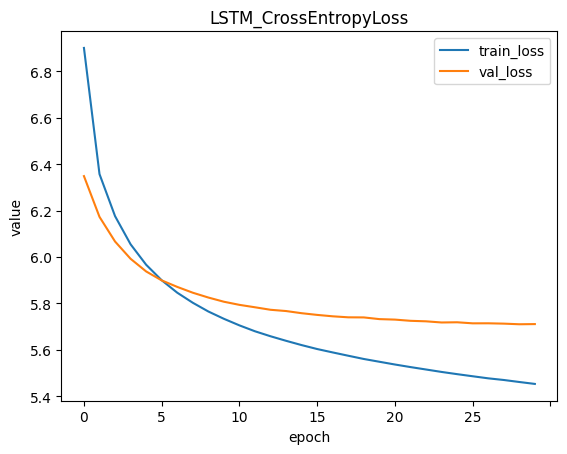

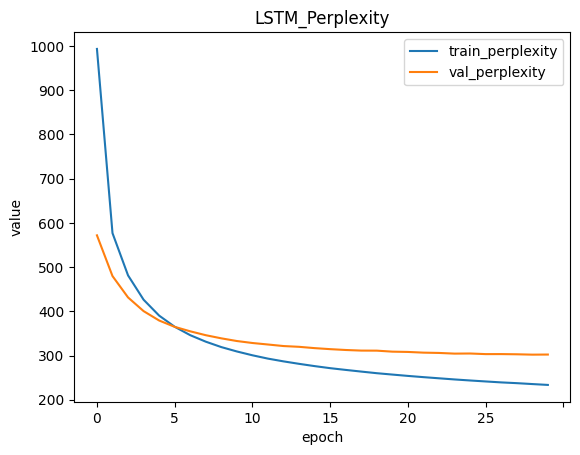

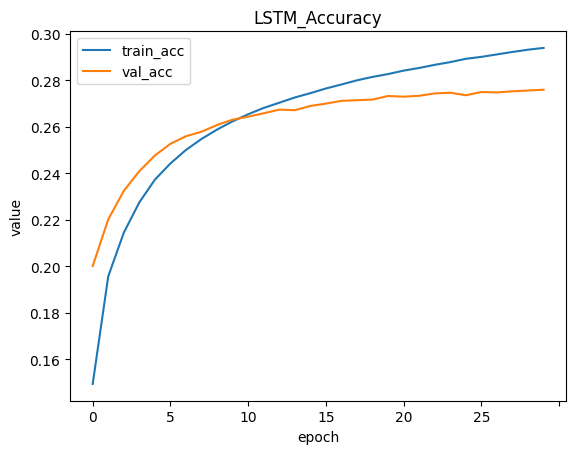

,time,epoch,train_loss,train_acc,train_perplexity,val_loss,val_acc,val_perplexity
0,2026_05_25T21_57_48,0,6.900962,0.149399,993.229722,6.348719,0.200137,571.759683
1,2026_05_25T21_57_59,1,6.357396,0.195690,576.742441,6.173069,0.220201,479.655927
2,2026_05_25T21_58_11,2,6.176308,0.214490,481.211949,6.066919,0.232475,431.349513
3,2026_05_25T21_58_23,3,6.054910,0.227548,426.200348,5.992467,0.240970,400.401206
4,2026_05_25T21_58_34,4,5.966836,0.237304,390.268992,5.937994,0.247714,379.173421
5,2026_05_25T21_58_45,5,5.900034,0.244292,365.049926,5.899441,0.252756,364.833605
6,2026_05_25T21_58_56,6,5.846421,0.250108,345.993830,5.871390,0.256006,354.741795
7,2026_05_25T21_59_08,7,5.803068,0.254833,331.314367,5.846320,0.257940,345.958809
8,2026_05_25T21_59_19,8,5.765410,0.258870,319.069772,5.825588,0.260840,338.860166
9,2026_05_25T21_59_30,9,5.733941,0.262412,309.185338,5.807497,0.263143,332.785053


In [16]:
lstm_train_metrics_df.plot(
    x="epoch",
    y=["train_loss", "val_loss"],
    title="LSTM_CrossEntropyLoss",
    xlabel="epoch",
    ylabel="value",
    sharex=False,
    sharey=False,
)
plt.show()

lstm_train_metrics_df.plot(
    x="epoch",
    y=["train_perplexity", "val_perplexity"],
    title="LSTM_Perplexity",
    xlabel="epoch",
    ylabel="value",
    sharex=False,
    sharey=False,
)
plt.show()

lstm_train_metrics_df.plot(
    x="epoch",
    y=["train_acc", "val_acc"],
    title="LSTM_Accuracy",
    xlabel="epoch",
    ylabel="value",
    sharex=False,
    sharey=False,
)
plt.show()


display(lstm_train_metrics_df)

## Обучение GRU

In [17]:
print("Параметры")
config["model"]["model_type"] = "GRU"
pprint(config["model"])

Параметры
{'checkpoint_name': None,
 'model_params': {'dropout': 0.2,
                  'embedding_size': 128,
                  'hidden_size': 128,
                  'n_rec_layers': 4,
                  'resid_connections': True},
 'model_type': 'GRU'}


In [18]:
gru_train_metrics_df, _ = train(config, logger=nb_logger)
del _

2026-05-25 22:03:14,854 INFO Start training
INFO:txt_logger:Start training
2026-05-25 22:03:14,855 DEBUG Parameters: {'data_dir': './data/', 'models_dir': './models/', 'metrics_dir': './metrics/', 'plots_dir': './plots/', 'tokenizer': {'max_len': 150, 'n_most_freq_words': 10000}, 'model': {'model_type': 'GRU', 'model_params': {'embedding_size': 128, 'n_rec_layers': 4, 'hidden_size': 128, 'dropout': 0.2, 'resid_connections': True}, 'checkpoint_name': None}, 'optimizer_params': {'lr': 0.001, 'weight_decay': 0.01}, 'grad_clipping_params': {'max_norm': 1.0, 'norm_type': 2.0}, 'training_params': {'n_epochs': 30, 'batch_size': 128, 'num_workers': 8, 'label_smoothing': 0.2}, 'distilgpt2': {'max_len': 512, 'min_text_len': 10, 'batch_size': 64, 'generate_max_new_tokens': 1}}
DEBUG:txt_logger:Parameters: {'data_dir': './data/', 'models_dir': './models/', 'metrics_dir': './metrics/', 'plots_dir': './plots/', 'tokenizer': {'max_len': 150, 'n_most_freq_words': 10000}, 'model': {'model_type': 'GRU',

  0%|          | 0/30 [00:00<?, ?it/s]

2026-05-25 22:03:16,987 INFO Epoch 0 / 30. Training
INFO:txt_logger:Epoch 0 / 30. Training


  0%|          | 0/227 [00:00<?, ?it/s]

2026-05-25 22:03:27,415 INFO Epoch 0 / 30. Validation
INFO:txt_logger:Epoch 0 / 30. Validation


...

2026-05-25 22:08:42,532 INFO Epoch 28 / 30. Metrics: {'time': '2026_05_25T22_08_42', 'epoch': 28, 'train_loss': 5.486500455769856, 'train_perplexity': 241.4108987575128, 'train_acc': 0.28886227450431257, 'val_loss': 5.741077023490716, 'val_acc': 0.27254582003074374, 'val_perplexity': 311.3996151381185}
INFO:txt_logger:Epoch 28 / 30. Metrics: {'time': '2026_05_25T22_08_42', 'epoch': 28, 'train_loss': 5.486500455769856, 'train_perplexity': 241.4108987575128, 'train_acc': 0.28886227450431257, 'val_loss': 5.741077023490716, 'val_acc': 0.27254582003074374, 'val_perplexity': 311.3996151381185}
2026-05-25 22:08:42,536 INFO Save metrics to metrics/metrics_2026_05_25T22_03_16.csv
INFO:txt_logger:Save metrics to metrics/metrics_2026_05_25T22_03_16.csv
2026-05-25 22:08:42,575 INFO Checkpoint saved to models/GRU_epoch_0028_2026_05_25T22_08_42.pt
INFO:txt_logger:Checkpoint saved to models/GRU_epoch_0028_2026_05_25T22_08_42.pt
2026-05-25 22:08:42,576 INFO Epoch 29 / 30. Training
INFO:txt_logger:Epoc

  0%|          | 0/227 [00:00<?, ?it/s]

2026-05-25 22:08:53,231 INFO Epoch 29 / 30. Validation
INFO:txt_logger:Epoch 29 / 30. Validation


  0%|          | 0/24 [00:00<?, ?it/s]

2026-05-25 22:08:53,971 INFO Epoch 29 / 30. Metrics: {'time': '2026_05_25T22_08_53', 'epoch': 29, 'train_loss': 5.478140432545064, 'train_perplexity': 239.40111068000974, 'train_acc': 0.2896679376158387, 'val_loss': 5.740252841738814, 'val_acc': 0.2721863544992314, 'val_perplexity': 311.1430709917963}
INFO:txt_logger:Epoch 29 / 30. Metrics: {'time': '2026_05_25T22_08_53', 'epoch': 29, 'train_loss': 5.478140432545064, 'train_perplexity': 239.40111068000974, 'train_acc': 0.2896679376158387, 'val_loss': 5.740252841738814, 'val_acc': 0.2721863544992314, 'val_perplexity': 311.1430709917963}
2026-05-25 22:08:53,975 INFO Save metrics to metrics/metrics_2026_05_25T22_03_16.csv
INFO:txt_logger:Save metrics to metrics/metrics_2026_05_25T22_03_16.csv
2026-05-25 22:08:54,047 INFO Checkpoint saved to models/GRU_epoch_0029_2026_05_25T22_08_53.pt
INFO:txt_logger:Checkpoint saved to models/GRU_epoch_0029_2026_05_25T22_08_53.pt


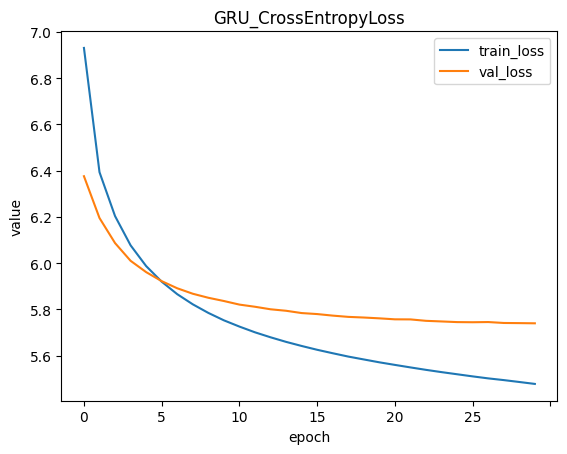

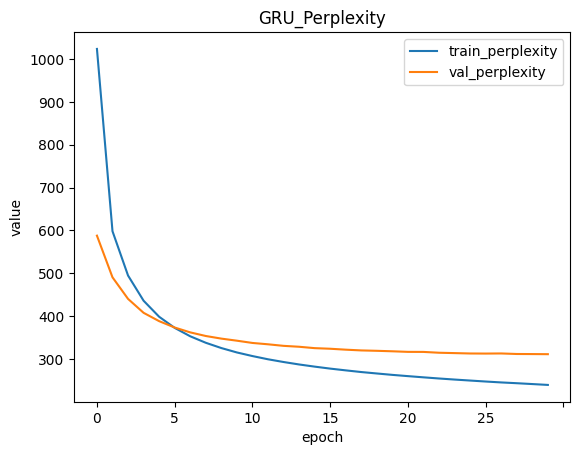

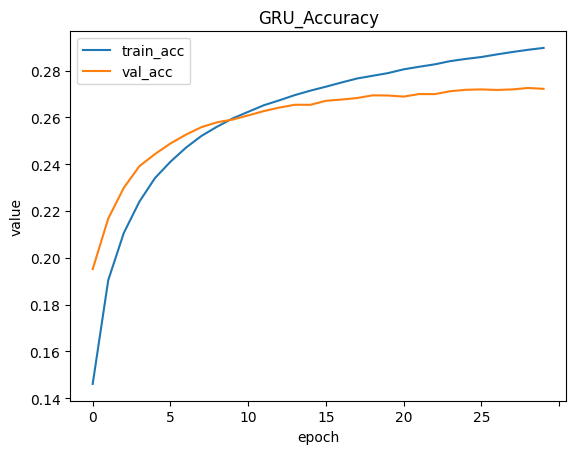

,time,epoch,train_loss,train_acc,train_perplexity,val_loss,val_acc,val_perplexity
0,2026_05_25T22_03_28,0,6.931062,0.146088,1023.580814,6.376325,0.195142,587.763949
1,2026_05_25T22_03_39,1,6.393736,0.190435,598.087130,6.195526,0.216781,490.549196
2,2026_05_25T22_03_50,2,6.203949,0.210586,494.698763,6.087184,0.229888,440.180118
3,2026_05_25T22_04_01,3,6.077419,0.223939,435.902841,6.010478,0.239106,407.678199
4,2026_05_25T22_04_13,4,5.987714,0.234010,398.502561,5.961596,0.244290,388.229383
5,2026_05_25T22_04_24,5,5.920268,0.241029,372.511527,5.922554,0.248840,373.364205
6,2026_05_25T22_04_35,6,5.866185,0.247059,352.900130,5.891745,0.252629,362.036494
7,2026_05_25T22_04_46,7,5.822353,0.252091,337.765818,5.868084,0.255840,353.570874
8,2026_05_25T22_04_57,8,5.785212,0.256018,325.451059,5.850688,0.257879,347.473283
9,2026_05_25T22_05_09,9,5.753134,0.259539,315.177025,5.836650,0.259061,342.629650


In [19]:
gru_train_metrics_df.plot(
    x="epoch",
    y=["train_loss", "val_loss"],
    title="GRU_CrossEntropyLoss",
    xlabel="epoch",
    ylabel="value",
    sharex=False,
    sharey=False,
)
plt.show()

gru_train_metrics_df.plot(
    x="epoch",
    y=["train_perplexity", "val_perplexity"],
    title="GRU_Perplexity",
    xlabel="epoch",
    ylabel="value",
    sharex=False,
    sharey=False,
)
plt.show()

gru_train_metrics_df.plot(
    x="epoch",
    y=["train_acc", "val_acc"],
    title="GRU_Accuracy",
    xlabel="epoch",
    ylabel="value",
    sharex=False,
    sharey=False,
)
plt.show()


display(gru_train_metrics_df)

### Обучение LSTM и GRU - выводы

- Количество парамтеров модели на основе LSTM 3 099 408. В логе и выводе ячейки
есть записть:
    ```
    INFO:txt_logger:Initialized the model. Model type: LSTM
    2026-05-25 21:57:36,389 INFO Total parameters: 3,099,408
    ```
- Количество парамтеров модели на основе GRU 2 967 312. В логе и выводе ячейки
есть записть:
    ```
    INFO:txt_logger:Initialized the model. Model type: GRU
    2026-05-25 22:03:16,979 INFO Total parameters: 2,967,312
    ```
- Кривые обучения LSTM и GRU гладкие, модели продолжают обучаться, значит удалось избежать
как взрыва так и затухания градиента. Положительный эффект мог оказать как LayerNorm,
так и gradient_clipping (см. парамтер `grad_clipping_params` *config.py*), так
и residual_connections между слоями LSTM. Ответ на вопрос о важности каждого из
этих элементов выходит за рамки поставленной задачи.
- Скорость обучения LSTM примерно 11 с / эпоха.
- Модель на основе LSTM демонстрирует overfittning, обучение следует остановить
приблизительно на 20й эпохе (в дальнейшем анализе будем загружать именно эту
контрольную точку).
- **Метрики LSTM на 20й эпохе**:
    | epoch | train_loss | train_acc | train_perplexity | val_loss | val_acc  | val_perplexity |
    |-------|------------|-----------|------------------|----------|----------|----------------|
    | 20    | 5.537043   | 0.284238  | 253.925985       | 5.730490 | 0.273019 | 308.120210     |

- Скорость обучения GRU примерно 11 с / эпоха.
- Модель на основе GRU демонстрирует overfittning, обучение следует остановить
приблизительно на 20й эпохе (в дальнейшем анализе будем загружать именно эту
контрольную точку).
- **Метрики GRU на 20й эпохе**:
    | epoch | train_loss | train_acc | train_perplexity | val_loss | val_acc  | val_perplexity |
    |-------|------------|-----------|------------------|----------|----------|----------------|
    | 20    | 5.560384   | 0.280523  | 259.922580       | 5.757470 | 0.268871 | 316.546426     |
- Модели показывают сопоставимые результаты по скорости и качеству. GRU имеет
меньше параметров, скорее всего её будет легче обучать на реальной задаче, но
её val_perplexity выше, значит он менее уверенна в прогнозе и будет предлагать
более разнообразные варианты дополнения текста.

## Тест LSTM

Оценим метрики LSTM на тестовом подмножестве

In [20]:
config["model"]["checkpoint_name"] = "LSTM_epoch_0020_2026_05_25T22_01_33.pt"
config["model"]["model_type"] = "LSTM"

lstm_test_metrics = test_custom_model(config, logger=nb_logger)
display(lstm_test_metrics)

config["model"]["checkpoint_name"] = None

2026-05-25 22:13:16,987 INFO Start custom model test
INFO:txt_logger:Start custom model test
2026-05-25 22:13:16,987 DEBUG Parameters: {'data_dir': './data/', 'models_dir': './models/', 'metrics_dir': './metrics/', 'plots_dir': './plots/', 'tokenizer': {'max_len': 150, 'n_most_freq_words': 10000}, 'model': {'model_type': 'LSTM', 'model_params': {'embedding_size': 128, 'n_rec_layers': 4, 'hidden_size': 128, 'dropout': 0.2, 'resid_connections': True}, 'checkpoint_name': 'LSTM_epoch_0020_2026_05_25T22_01_33.pt'}, 'optimizer_params': {'lr': 0.001, 'weight_decay': 0.01}, 'grad_clipping_params': {'max_norm': 1.0, 'norm_type': 2.0}, 'training_params': {'n_epochs': 30, 'batch_size': 128, 'num_workers': 8, 'label_smoothing': 0.2}, 'distilgpt2': {'max_len': 512, 'min_text_len': 10, 'batch_size': 64, 'generate_max_new_tokens': 1}}
DEBUG:txt_logger:Parameters: {'data_dir': './data/', 'models_dir': './models/', 'metrics_dir': './metrics/', 'plots_dir': './plots/', 'tokenizer': {'max_len': 150, 'n_m

  0%|          | 0/28 [00:00<?, ?it/s]

2026-05-25 22:13:18,965 INFO Test metrics: {'loss': 5.682895601564064, 'acc': 0.2766826116146358, 'perplexity': 293.7989240547456}
INFO:txt_logger:Test metrics: {'loss': 5.682895601564064, 'acc': 0.2766826116146358, 'perplexity': 293.7989240547456}
2026-05-25 22:13:18,970 INFO Save metrics to metrics/test_metrics_LSTM_2026_05_25T22_13_18.csv
INFO:txt_logger:Save metrics to metrics/test_metrics_LSTM_2026_05_25T22_13_18.csv


,loss,acc,perplexity
0,5.682896,0.276683,293.798924


Результаты сопоставимы с результатами полученными на валидационном множестве,
значит модель работает корректно.

Полученные метрики:
| loss     | acc      | perplexity |
|----------|----------|------------|
| 5.682896 | 0.276683 | 293.798924 |

## Тест GRU

Оценим метрики GRU на тестовом подмножестве

In [21]:
config["model"]["checkpoint_name"] = "GRU_epoch_0020_2026_05_25T22_07_12.pt"
config["model"]["model_type"] = "GRU"

gru_test_metrics = test_custom_model(config, logger=nb_logger)
display(gru_test_metrics)

config["model"]["checkpoint_name"] = None

2026-05-25 22:13:45,626 INFO Start custom model test
INFO:txt_logger:Start custom model test
2026-05-25 22:13:45,627 DEBUG Parameters: {'data_dir': './data/', 'models_dir': './models/', 'metrics_dir': './metrics/', 'plots_dir': './plots/', 'tokenizer': {'max_len': 150, 'n_most_freq_words': 10000}, 'model': {'model_type': 'GRU', 'model_params': {'embedding_size': 128, 'n_rec_layers': 4, 'hidden_size': 128, 'dropout': 0.2, 'resid_connections': True}, 'checkpoint_name': 'GRU_epoch_0020_2026_05_25T22_07_12.pt'}, 'optimizer_params': {'lr': 0.001, 'weight_decay': 0.01}, 'grad_clipping_params': {'max_norm': 1.0, 'norm_type': 2.0}, 'training_params': {'n_epochs': 30, 'batch_size': 128, 'num_workers': 8, 'label_smoothing': 0.2}, 'distilgpt2': {'max_len': 512, 'min_text_len': 10, 'batch_size': 64, 'generate_max_new_tokens': 1}}
DEBUG:txt_logger:Parameters: {'data_dir': './data/', 'models_dir': './models/', 'metrics_dir': './metrics/', 'plots_dir': './plots/', 'tokenizer': {'max_len': 150, 'n_mos

  0%|          | 0/28 [00:00<?, ?it/s]

2026-05-25 22:13:47,562 INFO Test metrics: {'loss': 5.706593723175469, 'acc': 0.2732880161127895, 'perplexity': 300.8445611351785}
INFO:txt_logger:Test metrics: {'loss': 5.706593723175469, 'acc': 0.2732880161127895, 'perplexity': 300.8445611351785}
2026-05-25 22:13:47,568 INFO Save metrics to metrics/test_metrics_GRU_2026_05_25T22_13_47.csv
INFO:txt_logger:Save metrics to metrics/test_metrics_GRU_2026_05_25T22_13_47.csv


,loss,acc,perplexity
0,5.706594,0.273288,300.844561


Результаты сопоставимы с результатами полученными на валидационном множестве,
значит модель работает корректно.

Полученные метрики:
| loss     | acc      | perplexity |
|----------|----------|------------|
| 5.706594 | 0.273288 | 300.844561 |

**По метрикам на тесте GRU проигрывает LSTM**

## Тест DistilGPT2

Оценим метрики DistilGPT2 (предобученные трансформер) на тестовом подмножестве

In [22]:
gpt2_test_metrics = test_distilgpt2(config, logger=nb_logger)
display(gpt2_test_metrics)

2026-05-25 22:13:53,081 INFO Test distilbert/distilgpt2
INFO:txt_logger:Test distilbert/distilgpt2
2026-05-25 22:13:53,082 DEBUG Parameters: {'data_dir': './data/', 'models_dir': './models/', 'metrics_dir': './metrics/', 'plots_dir': './plots/', 'tokenizer': {'max_len': 150, 'n_most_freq_words': 10000}, 'model': {'model_type': 'GRU', 'model_params': {'embedding_size': 128, 'n_rec_layers': 4, 'hidden_size': 128, 'dropout': 0.2, 'resid_connections': True}, 'checkpoint_name': None}, 'optimizer_params': {'lr': 0.001, 'weight_decay': 0.01}, 'grad_clipping_params': {'max_norm': 1.0, 'norm_type': 2.0}, 'training_params': {'n_epochs': 30, 'batch_size': 128, 'num_workers': 8, 'label_smoothing': 0.2}, 'distilgpt2': {'max_len': 512, 'min_text_len': 10, 'batch_size': 64, 'generate_max_new_tokens': 1}}
DEBUG:txt_logger:Parameters: {'data_dir': './data/', 'models_dir': './models/', 'metrics_dir': './metrics/', 'plots_dir': './plots/', 'tokenizer': {'max_len': 150, 'n_most_freq_words': 10000}, 'model

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Map:   0%|          | 0/2880 [00:00<?, ? examples/s]

2026-05-25 22:13:59,505 INFO Tokenized dataset
2026-05-25 22:13:59,505 INFO Tokenized dataset
INFO:txt_logger:Tokenized dataset
2026-05-25 22:13:59,506 INFO Created data_collator
2026-05-25 22:13:59,506 INFO Created data_collator
INFO:txt_logger:Created data_collator
2026-05-25 22:13:59,507 INFO Created test DataLoader
2026-05-25 22:13:59,507 INFO Created test DataLoader
INFO:txt_logger:Created test DataLoader
2026-05-25 22:13:59,507 INFO Selected device: cuda
2026-05-25 22:13:59,507 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:13:59,507 INFO Total parameters: 81,912,576
2026-05-25 22:13:59,507 INFO Total parameters: 81,912,576
INFO:txt_logger:Total parameters: 81,912,576
2026-05-25 22:13:59,592 INFO Evaluate model on test set
2026-05-25 22:13:59,592 INFO Evaluate model on test set
INFO:txt_logger:Evaluate model on test set


  0%|          | 0/45 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
2026-05-25 22:14:04,113 INFO Test metrics: {'loss': 4.309362860326759, 'acc': 0.28099394657144794, 'perplexity': 74.39307505778291}
2026-05-25 22:14:04,113 INFO Test metrics: {'loss': 4.309362860326759, 'acc': 0.28099394657144794, 'perplexity': 74.39307505778291}
INFO:txt_logger:Test metrics: {'loss': 4.309362860326759, 'acc': 0.28099394657144794, 'perplexity': 74.39307505778291}
2026-05-25 22:14:04,118 INFO Save metrics to metrics/test_metrics_distilgpt2_2026_05_25T22_14_04.csv
2026-05-25 22:14:04,118 INFO Save metrics to metrics/test_metrics_distilgpt2_2026_05_25T22_14_04.csv
INFO:txt_logger:Save metrics to metrics/test_metrics_distilgpt2_2026_05_25T22_14_04.csv


,loss,acc,perplexity
0,4.309363,0.280994,74.393075


Полученные метрики:
| loss     | acc      | perplexity |
|----------|----------|------------|
| 4.309363 | 0.280994 | 74.393075  |

**Результаты DistilGPT2 значительно лучше, чем результаты GRU и LSTM**

*Сравнение с DistilGPT2 нечестное, так как DistilGPT2 была обучена на другом
датасете и имеер значительно больший словарь.*

**DistilGPT2 имеет почти в 30 раз больше параметров, чем модели конкуренты:**
```
2026-05-25 22:13:59,155 INFO DistilGPT2 Total parameters: 81 912 576
```

## Примеры предсказаний

### LSTM

In [23]:
config["model"]["checkpoint_name"] = "LSTM_epoch_0020_2026_05_25T22_01_33.pt"
config["model"]["model_type"] = "LSTM"

predicted_text = predict_custom_model("London is the capital of Great", config, logger=nb_logger)

2026-05-25 22:15:01,162 INFO Start inference
2026-05-25 22:15:01,162 INFO Start inference
INFO:txt_logger:Start inference
2026-05-25 22:15:01,209 INFO Initialized the tokenizer
2026-05-25 22:15:01,209 INFO Initialized the tokenizer
INFO:txt_logger:Initialized the tokenizer
2026-05-25 22:15:01,210 INFO Selected device: cuda
2026-05-25 22:15:01,210 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:01,218 INFO Initialized the model. Model type: LSTM
2026-05-25 22:15:01,218 INFO Initialized the model. Model type: LSTM
INFO:txt_logger:Initialized the model. Model type: LSTM
2026-05-25 22:15:01,219 INFO Total parameters: 3,099,408
2026-05-25 22:15:01,219 INFO Total parameters: 3,099,408
INFO:txt_logger:Total parameters: 3,099,408
2026-05-25 22:15:01,235 INFO Loaded checkpoint from models/LSTM_epoch_0020_2026_05_25T22_01_33.pt
2026-05-25 22:15:01,235 INFO Loaded checkpoint from models/LSTM_epoch_0020_2026_05_25T22_01_33.pt
INFO:txt_logger:Loaded checkpoint from

London is the capital of Great...

In [24]:
predicted_text[-1]

'Britain'

In [25]:
predicted_text = predict_custom_model("New York is a", config, logger=nb_logger)

2026-05-25 22:15:02,061 INFO Start inference
2026-05-25 22:15:02,061 INFO Start inference
INFO:txt_logger:Start inference
2026-05-25 22:15:02,096 INFO Initialized the tokenizer
2026-05-25 22:15:02,096 INFO Initialized the tokenizer
INFO:txt_logger:Initialized the tokenizer
2026-05-25 22:15:02,097 INFO Selected device: cuda
2026-05-25 22:15:02,097 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:02,105 INFO Initialized the model. Model type: LSTM
2026-05-25 22:15:02,105 INFO Initialized the model. Model type: LSTM
INFO:txt_logger:Initialized the model. Model type: LSTM
2026-05-25 22:15:02,105 INFO Total parameters: 3,099,408
2026-05-25 22:15:02,105 INFO Total parameters: 3,099,408
INFO:txt_logger:Total parameters: 3,099,408
2026-05-25 22:15:02,122 INFO Loaded checkpoint from models/LSTM_epoch_0020_2026_05_25T22_01_33.pt
2026-05-25 22:15:02,122 INFO Loaded checkpoint from models/LSTM_epoch_0020_2026_05_25T22_01_33.pt
INFO:txt_logger:Loaded checkpoint from

New York is a...

In [26]:
predicted_text[-1]

'<UNK>'

In [27]:
# Ironclads were widely used in South America .
predicted_text = predict_custom_model("Ironclads were widely used in South", config, logger=nb_logger)

2026-05-25 22:15:02,875 INFO Start inference
2026-05-25 22:15:02,875 INFO Start inference
INFO:txt_logger:Start inference
2026-05-25 22:15:02,908 INFO Initialized the tokenizer
2026-05-25 22:15:02,908 INFO Initialized the tokenizer
INFO:txt_logger:Initialized the tokenizer
2026-05-25 22:15:02,909 INFO Selected device: cuda
2026-05-25 22:15:02,909 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:02,917 INFO Initialized the model. Model type: LSTM
2026-05-25 22:15:02,917 INFO Initialized the model. Model type: LSTM
INFO:txt_logger:Initialized the model. Model type: LSTM
2026-05-25 22:15:02,918 INFO Total parameters: 3,099,408
2026-05-25 22:15:02,918 INFO Total parameters: 3,099,408
INFO:txt_logger:Total parameters: 3,099,408
2026-05-25 22:15:02,934 INFO Loaded checkpoint from models/LSTM_epoch_0020_2026_05_25T22_01_33.pt
2026-05-25 22:15:02,934 INFO Loaded checkpoint from models/LSTM_epoch_0020_2026_05_25T22_01_33.pt
INFO:txt_logger:Loaded checkpoint from

Ironclads were widely used in South...

In [28]:
predicted_text[-1]

'Africa'

In [29]:
predicted_text = predict_custom_model("Ironclads were widely", config, logger=nb_logger)

2026-05-25 22:15:03,774 INFO Start inference
2026-05-25 22:15:03,774 INFO Start inference
INFO:txt_logger:Start inference
2026-05-25 22:15:03,807 INFO Initialized the tokenizer
2026-05-25 22:15:03,807 INFO Initialized the tokenizer
INFO:txt_logger:Initialized the tokenizer
2026-05-25 22:15:03,808 INFO Selected device: cuda
2026-05-25 22:15:03,808 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:03,815 INFO Initialized the model. Model type: LSTM
2026-05-25 22:15:03,815 INFO Initialized the model. Model type: LSTM
INFO:txt_logger:Initialized the model. Model type: LSTM
2026-05-25 22:15:03,816 INFO Total parameters: 3,099,408
2026-05-25 22:15:03,816 INFO Total parameters: 3,099,408
INFO:txt_logger:Total parameters: 3,099,408
2026-05-25 22:15:03,833 INFO Loaded checkpoint from models/LSTM_epoch_0020_2026_05_25T22_01_33.pt
2026-05-25 22:15:03,833 INFO Loaded checkpoint from models/LSTM_epoch_0020_2026_05_25T22_01_33.pt
INFO:txt_logger:Loaded checkpoint from

Ironclads were widely...

In [30]:
predicted_text[-1]

'distributed'

Примечательно, что ответ модели близок по смыслу к оригинальному тексту (было "used").

### GRU

In [31]:
config["model"]["checkpoint_name"] = "GRU_epoch_0020_2026_05_25T22_07_12.pt"
config["model"]["model_type"] = "GRU"

predicted_text = predict_custom_model("London is the capital of Great", config, logger=nb_logger)

2026-05-25 22:15:05,160 INFO Start inference
2026-05-25 22:15:05,160 INFO Start inference
INFO:txt_logger:Start inference
2026-05-25 22:15:05,194 INFO Initialized the tokenizer
2026-05-25 22:15:05,194 INFO Initialized the tokenizer
INFO:txt_logger:Initialized the tokenizer
2026-05-25 22:15:05,195 INFO Selected device: cuda
2026-05-25 22:15:05,195 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:05,202 INFO Initialized the model. Model type: GRU
2026-05-25 22:15:05,202 INFO Initialized the model. Model type: GRU
INFO:txt_logger:Initialized the model. Model type: GRU
2026-05-25 22:15:05,203 INFO Total parameters: 2,967,312
2026-05-25 22:15:05,203 INFO Total parameters: 2,967,312
INFO:txt_logger:Total parameters: 2,967,312
2026-05-25 22:15:05,220 INFO Loaded checkpoint from models/GRU_epoch_0020_2026_05_25T22_07_12.pt
2026-05-25 22:15:05,220 INFO Loaded checkpoint from models/GRU_epoch_0020_2026_05_25T22_07_12.pt
INFO:txt_logger:Loaded checkpoint from mode

London is the capital of Great...

In [32]:
predicted_text[-1]

'Britain'

In [33]:
predicted_text = predict_custom_model("New York is a", config, logger=nb_logger)

2026-05-25 22:15:06,091 INFO Start inference
2026-05-25 22:15:06,091 INFO Start inference
INFO:txt_logger:Start inference
2026-05-25 22:15:06,126 INFO Initialized the tokenizer
2026-05-25 22:15:06,126 INFO Initialized the tokenizer
INFO:txt_logger:Initialized the tokenizer
2026-05-25 22:15:06,127 INFO Selected device: cuda
2026-05-25 22:15:06,127 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:06,136 INFO Initialized the model. Model type: GRU
2026-05-25 22:15:06,136 INFO Initialized the model. Model type: GRU
INFO:txt_logger:Initialized the model. Model type: GRU
2026-05-25 22:15:06,137 INFO Total parameters: 2,967,312
2026-05-25 22:15:06,137 INFO Total parameters: 2,967,312
INFO:txt_logger:Total parameters: 2,967,312
2026-05-25 22:15:06,153 INFO Loaded checkpoint from models/GRU_epoch_0020_2026_05_25T22_07_12.pt
2026-05-25 22:15:06,153 INFO Loaded checkpoint from models/GRU_epoch_0020_2026_05_25T22_07_12.pt
INFO:txt_logger:Loaded checkpoint from mode

New York is a...

In [34]:
predicted_text[-1]

'<UNK>'

In [35]:
# Ironclads were widely used in South America .
predicted_text = predict_custom_model("Ironclads were widely used in South", config, logger=nb_logger)

2026-05-25 22:15:07,063 INFO Start inference
2026-05-25 22:15:07,063 INFO Start inference
INFO:txt_logger:Start inference
2026-05-25 22:15:07,096 INFO Initialized the tokenizer
2026-05-25 22:15:07,096 INFO Initialized the tokenizer
INFO:txt_logger:Initialized the tokenizer
2026-05-25 22:15:07,096 INFO Selected device: cuda
2026-05-25 22:15:07,096 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:07,104 INFO Initialized the model. Model type: GRU
2026-05-25 22:15:07,104 INFO Initialized the model. Model type: GRU
INFO:txt_logger:Initialized the model. Model type: GRU
2026-05-25 22:15:07,105 INFO Total parameters: 2,967,312
2026-05-25 22:15:07,105 INFO Total parameters: 2,967,312
INFO:txt_logger:Total parameters: 2,967,312
2026-05-25 22:15:07,121 INFO Loaded checkpoint from models/GRU_epoch_0020_2026_05_25T22_07_12.pt
2026-05-25 22:15:07,121 INFO Loaded checkpoint from models/GRU_epoch_0020_2026_05_25T22_07_12.pt
INFO:txt_logger:Loaded checkpoint from mode

Ironclads were widely used in South...

In [36]:
predicted_text[-1]

'America'

Удивительно, но только GRU дала правильный ответ в этом примере.

In [37]:
predicted_text = predict_custom_model("Ironclads were widely", config, logger=nb_logger)

2026-05-25 22:15:10,414 INFO Start inference
2026-05-25 22:15:10,414 INFO Start inference
INFO:txt_logger:Start inference
2026-05-25 22:15:10,448 INFO Initialized the tokenizer
2026-05-25 22:15:10,448 INFO Initialized the tokenizer
INFO:txt_logger:Initialized the tokenizer
2026-05-25 22:15:10,449 INFO Selected device: cuda
2026-05-25 22:15:10,449 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:10,456 INFO Initialized the model. Model type: GRU
2026-05-25 22:15:10,456 INFO Initialized the model. Model type: GRU
INFO:txt_logger:Initialized the model. Model type: GRU
2026-05-25 22:15:10,457 INFO Total parameters: 2,967,312
2026-05-25 22:15:10,457 INFO Total parameters: 2,967,312
INFO:txt_logger:Total parameters: 2,967,312
2026-05-25 22:15:10,473 INFO Loaded checkpoint from models/GRU_epoch_0020_2026_05_25T22_07_12.pt
2026-05-25 22:15:10,473 INFO Loaded checkpoint from models/GRU_epoch_0020_2026_05_25T22_07_12.pt
INFO:txt_logger:Loaded checkpoint from mode

Ironclads were widely...

In [38]:
predicted_text[-1]

'considered'

### DistilGPT2

In [39]:
predicted_text = predict_distilgpt2("London is the capital of Great", config, logger=nb_logger)

2026-05-25 22:15:13,657 INFO Inference distilbert/distilgpt2
2026-05-25 22:15:13,657 INFO Inference distilbert/distilgpt2
INFO:txt_logger:Inference distilbert/distilgpt2
2026-05-25 22:15:14,249 INFO Loaded tokenizer to models/distilgpt2_tokenizer
2026-05-25 22:15:14,249 INFO Loaded tokenizer to models/distilgpt2_tokenizer
INFO:txt_logger:Loaded tokenizer to models/distilgpt2_tokenizer


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

2026-05-25 22:15:14,638 INFO Loaded model to models/distilgpt2_model
2026-05-25 22:15:14,638 INFO Loaded model to models/distilgpt2_model
INFO:txt_logger:Loaded model to models/distilgpt2_model
2026-05-25 22:15:14,639 INFO Selected device: cuda
2026-05-25 22:15:14,639 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:14,708 INFO Predicted text:
London is the capital of Great Britain
2026-05-25 22:15:14,708 INFO Predicted text:
London is the capital of Great Britain
INFO:txt_logger:Predicted text:
London is the capital of Great Britain


London is the capital of Great...

In [40]:
predicted_text.split()[-1]

'Britain'

In [41]:
predicted_text = predict_distilgpt2("New York is a", config, logger=nb_logger)

2026-05-25 22:15:14,721 INFO Inference distilbert/distilgpt2
2026-05-25 22:15:14,721 INFO Inference distilbert/distilgpt2
INFO:txt_logger:Inference distilbert/distilgpt2
2026-05-25 22:15:15,292 INFO Loaded tokenizer to models/distilgpt2_tokenizer
2026-05-25 22:15:15,292 INFO Loaded tokenizer to models/distilgpt2_tokenizer
INFO:txt_logger:Loaded tokenizer to models/distilgpt2_tokenizer


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

2026-05-25 22:15:15,683 INFO Loaded model to models/distilgpt2_model
2026-05-25 22:15:15,683 INFO Loaded model to models/distilgpt2_model
INFO:txt_logger:Loaded model to models/distilgpt2_model
2026-05-25 22:15:15,684 INFO Selected device: cuda
2026-05-25 22:15:15,684 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:15,748 INFO Predicted text:
New York is a city
2026-05-25 22:15:15,748 INFO Predicted text:
New York is a city
INFO:txt_logger:Predicted text:
New York is a city


New York is a...

In [42]:
predicted_text.split()[-1]

'city'

In [43]:
# Ironclads were widely used in South America .
predicted_text = predict_distilgpt2("Ironclads were widely used in South", config, logger=nb_logger)

2026-05-25 22:15:17,566 INFO Inference distilbert/distilgpt2
2026-05-25 22:15:17,566 INFO Inference distilbert/distilgpt2
INFO:txt_logger:Inference distilbert/distilgpt2
2026-05-25 22:15:18,149 INFO Loaded tokenizer to models/distilgpt2_tokenizer
2026-05-25 22:15:18,149 INFO Loaded tokenizer to models/distilgpt2_tokenizer
INFO:txt_logger:Loaded tokenizer to models/distilgpt2_tokenizer


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

2026-05-25 22:15:18,537 INFO Loaded model to models/distilgpt2_model
2026-05-25 22:15:18,537 INFO Loaded model to models/distilgpt2_model
INFO:txt_logger:Loaded model to models/distilgpt2_model
2026-05-25 22:15:18,538 INFO Selected device: cuda
2026-05-25 22:15:18,538 INFO Selected device: cuda
INFO:txt_logger:Selected device: cuda
2026-05-25 22:15:18,598 INFO Predicted text:
Ironclads were widely used in South Africa
2026-05-25 22:15:18,598 INFO Predicted text:
Ironclads were widely used in South Africa
INFO:txt_logger:Predicted text:
Ironclads were widely used in South Africa


Ironclads were widely used in South...

In [44]:
predicted_text.split()[-1]

'Africa'

## Выводы и рекомендации

- Если есть возможность разместить DistilGPT2 в памяти устройства или перенести
вычисления в облако, однозначно стоит отдать предпочтение этой модели (лучшее значение
perplexity - в 4 раза ниже чем у конкурентов).
- Модель LSTM работает не сильно медленнее и имеет не сиольно больше параметров
чем GRU, поэтому стоит отдать предпочтение LSTM, если использование DistilGPT2
невозможно.
- Одинаковая скорость трененга LSTM и GRU может быть объяснена использованем
мощной видеокарты и большого размера батча.
- Все 3 модели способны корректно прогнозировать последний токен последовательности,
и все 3 совершают ошибки.
- LSTM и GRU очень чувствительны к размеру словаря. Увеличение словаря усиливает
оверфитинг.
- Субьективно, для задачи предсказания следующего токена (при условии, что вычисления
производятся на носимом устройстве) использование рекуррентных неронных сетей и
трансформеров неоправданно (высокая вычислительная сложность на инференсе), можно
было бы попробовать обойтись моделью рассматривающую частоту встречаемости n-грамм.

## Остановка и удаление окружения

Код специфичный для Google Colab

In [45]:
from google.colab import runtime
runtime.unassign()